In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results1_small_world/results
Found 32 node metric files

/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results2_scalefree
Found 64 node metric files

/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results3_small_world
Found 23 node metric files

/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results4_scalefree
Found 23 node metric files

/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results5_smallworld
Found 26 node metric files

/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results6_scalefree
Found 24 node metric files


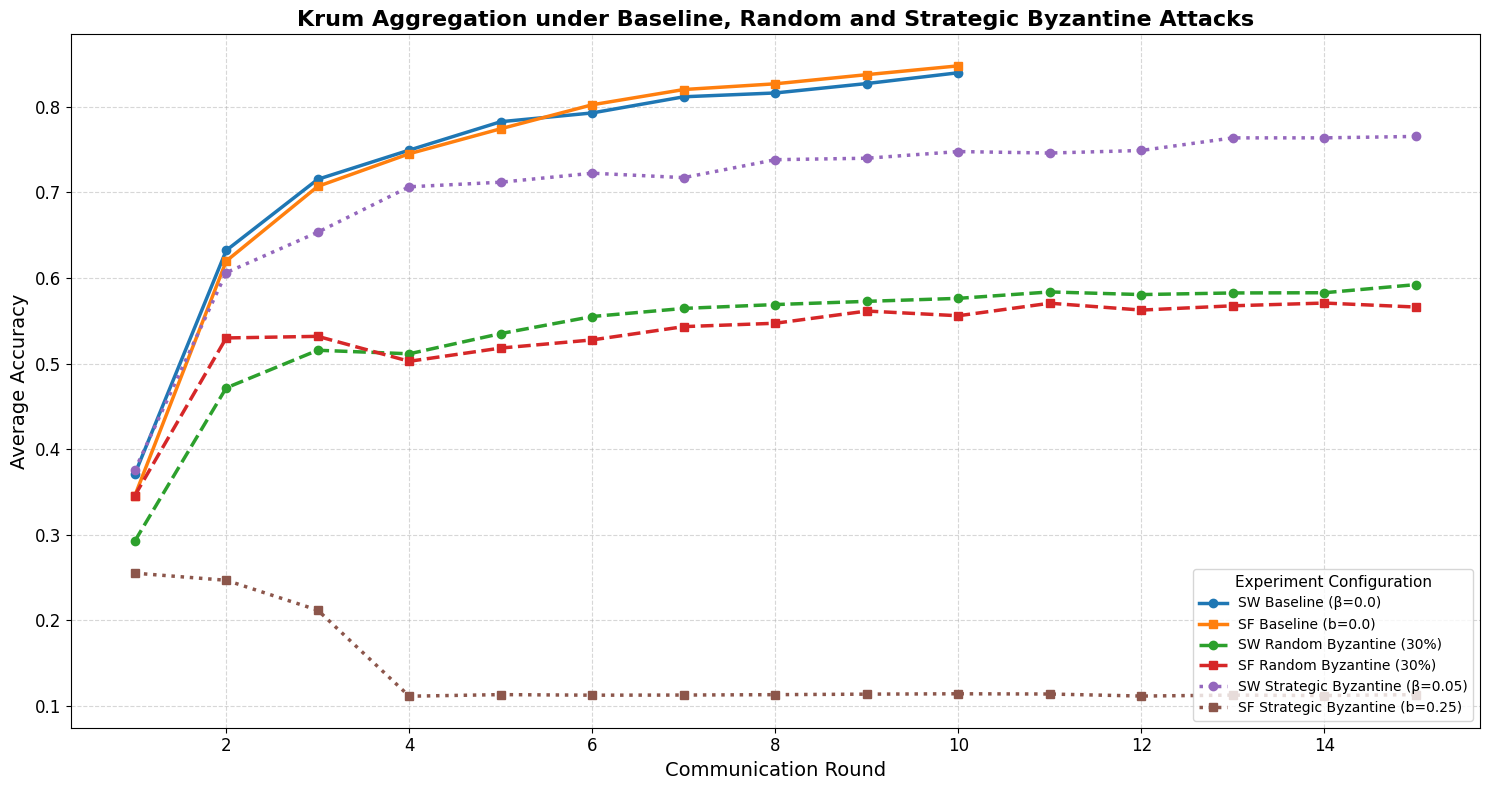

In [10]:
# =====================================================
# ALL 6 KRUM EXPERIMENTS
# FINAL RESEARCH PAPER STYLE PLOT
# =====================================================

import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PATHS
# =====================================================

paths = {

    "SW Baseline (β=0.0)":
    "/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results1_small_world/results",

    "SF Baseline (b=0.0)":
    "/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results2_scalefree",

    "SW Random Byzantine (30%)":
    "/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results3_small_world",

    "SF Random Byzantine (30%)":
    "/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results4_scalefree",

    "SW Strategic Byzantine (β=0.05)":
    "/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results5_smallworld",

    "SF Strategic Byzantine (b=0.25)":
    "/kaggle/input/datasets/poonamgupta123/federative-learning-datsset/results6_scalefree",
}

# =====================================================
# FUNCTION
# =====================================================

def load_avg_accuracy(base_path):

    json_files = glob.glob(
        os.path.join(base_path, "**", "node_metrics", "*.json"),
        recursive=True
    )

    print(f"\n{base_path}")
    print(f"Found {len(json_files)} node metric files")

    all_acc = []

    for file in json_files:

        try:
            with open(file, "r") as f:
                data = json.load(f)

            if "accuracies" in data:
                all_acc.append(data["accuracies"])

        except Exception as e:
            print(file, e)

    if len(all_acc) == 0:
        return None

    min_len = min(len(x) for x in all_acc)

    all_acc = [x[:min_len] for x in all_acc]

    return np.mean(np.array(all_acc), axis=0)

# =====================================================
# STYLES
# =====================================================

styles = {

    "SW Baseline (β=0.0)":
    dict(marker='o', linestyle='-'),

    "SF Baseline (b=0.0)":
    dict(marker='s', linestyle='-'),

    "SW Random Byzantine (30%)":
    dict(marker='o', linestyle='--'),

    "SF Random Byzantine (30%)":
    dict(marker='s', linestyle='--'),

    "SW Strategic Byzantine (β=0.05)":
    dict(marker='o', linestyle=':'),

    "SF Strategic Byzantine (b=0.25)":
    dict(marker='s', linestyle=':')
}

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(15,8))

for label, folder in paths.items():

    avg_acc = load_avg_accuracy(folder)

    if avg_acc is None:
        print(f"Skipping {label}")
        continue

    rounds = np.arange(1, len(avg_acc)+1)

    plt.plot(
        rounds,
        avg_acc,
        linewidth=2.5,
        markersize=6,
        label=label,
        marker=styles[label]["marker"],
        linestyle=styles[label]["linestyle"]
    )

# =====================================================
# LABELS
# =====================================================

plt.title(
    "Krum Aggregation under Baseline, Random and Strategic Byzantine Attacks",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Communication Round",
    fontsize=14
)

plt.ylabel(
    "Average Accuracy",
    fontsize=14
)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(
    title="Experiment Configuration",
    fontsize=10,
    title_fontsize=11,
    loc="lower right"
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()